# 01 — Dataset Overview

Catalogue-level statistics for TinyShip-Fingerprint corpora.

**Rules:** no model training; no scientific train/val/test splits; do not invent missing metadata.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.manifest import MANIFEST_COLUMNS, read_manifest, empty_manifest

META = ROOT / 'data' / 'metadata'
RAW = ROOT / 'data' / 'raw'
AUDIO_EXTS = {'.wav', '.flac', '.mp3', '.ogg'}

manifest_files = {
    'DeepShip': META / 'deepship_manifest.csv',
    'QiandaoEar22': META / 'qiandaoear22_manifest.csv',
    'ShipsEar': META / 'shipsear_manifest.csv',
}

frames = []
for name, path in manifest_files.items():
    df = read_manifest(path)
    if not df.empty:
        frames.append(df)

manifest = pd.concat(frames, ignore_index=True) if frames else empty_manifest()
print('Manifest rows:', len(manifest))
manifest.head()

Manifest rows: 18971


,dataset,file_path,recording_id,ship_id,mmsi,ship_type,duration_seconds,sample_rate,channels,source_location,recording_date,session_id,distance,audibility,target_count,is_background,original_filename,sha256,file_size_bytes
0,DeepShip,D:/TinyShip-Finger/data/raw/deepship/Cargo/103...,103,NaN,NaN,Cargo,NaN,NaN,NaN,Strait of Georgia (per DeepShip paper),NaN,NaN,NaN,NaN,NaN,False,103.wav,a90dd2a867674521867b7cd48a23a1d649d8fc3dceff61...,25472058
1,DeepShip,D:/TinyShip-Finger/data/raw/deepship/Cargo/110...,110,NaN,NaN,Cargo,NaN,NaN,NaN,Strait of Georgia (per DeepShip paper),NaN,NaN,NaN,NaN,NaN,False,110.wav,68953fdc86accd13d0528aa21f5ec6b31ce4c6d0438884...,25856058
2,DeepShip,D:/TinyShip-Finger/data/raw/deepship/Cargo/15.wav,15,NaN,NaN,Cargo,NaN,NaN,NaN,Strait of Georgia (per DeepShip paper),NaN,NaN,NaN,NaN,NaN,False,15.wav,a899976dfb3187e81b87825587fbad2593d8621aef8716...,23936058
3,DeepShip,D:/TinyShip-Finger/data/raw/deepship/Cargo/27.wav,27,NaN,NaN,Cargo,NaN,NaN,NaN,Strait of Georgia (per DeepShip paper),NaN,NaN,NaN,NaN,NaN,False,27.wav,cdf54f9b1ae2cc9e9b2e455a4d4219deabe24ab5710ea5...,25088058
4,DeepShip,D:/TinyShip-Finger/data/raw/deepship/Cargo/38.wav,38,NaN,NaN,Cargo,NaN,NaN,NaN,Strait of Georgia (per DeepShip paper),NaN,NaN,NaN,NaN,NaN,False,38.wav,8d7a6b085ec4534cfdc431a8fe193f27b13ef33b970411...,25088058


In [2]:
def scan_raw(dataset: str) -> dict:
    root = RAW / dataset
    files = [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in AUDIO_EXTS] if root.exists() else []
    return {
        'dataset': dataset,
        'n_files': len(files),
        'total_bytes': sum(p.stat().st_size for p in files),
    }

raw_stats = pd.DataFrame([scan_raw(d) for d in ['vtuad', 'deepship', 'qiandaoear22', 'shipsear']])
raw_stats

,dataset,n_files,total_bytes
0,vtuad,175965,22533725970
1,deepship,126,1465095308
2,qiandaoear22,18919,14321956368
3,shipsear,4,90957736


In [3]:
def summarize(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=['dataset','n_files','n_ships','n_classes','total_duration_s','background_pct'])
    rows = []
    for ds, g in df.groupby('dataset'):
        n_ships = g['ship_id'].nunique(dropna=True)
        n_classes = g['ship_type'].nunique(dropna=True)
        dur = g['duration_seconds'].dropna().sum() if 'duration_seconds' in g else float('nan')
        bg = g['is_background'].fillna(False).astype(bool).mean() * 100 if 'is_background' in g else float('nan')
        rows.append({
            'dataset': ds,
            'n_files': len(g),
            'n_ships': n_ships,
            'n_classes': n_classes,
            'total_duration_s': dur,
            'background_pct': bg,
        })
    return pd.DataFrame(rows)

summary = summarize(manifest)
summary

,dataset,n_files,n_ships,n_classes,total_duration_s,background_pct
0,DeepShip,63,1,3,0.0,0.000000
1,QiandaoEar22,18904,3,3,0.0,0.185146
2,ShipsEar,4,0,0,0.0,0.000000


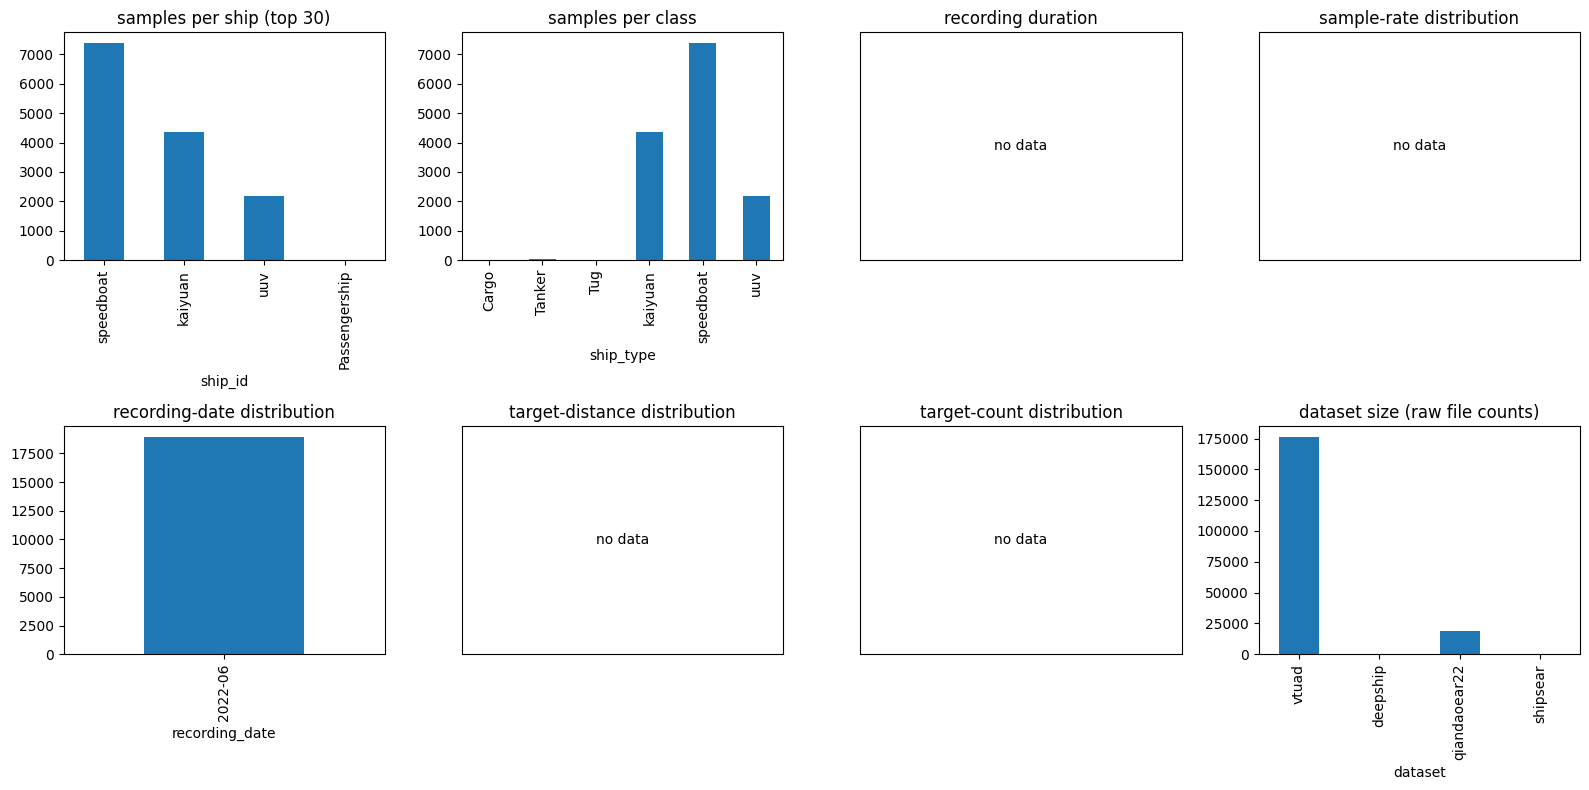

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

def safe_bar(ax, series, title):
    ax.set_title(title)
    if series is None or len(series) == 0:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        return
    series.plot(kind='bar', ax=ax)

if not manifest.empty:
    safe_bar(axes[0], manifest.groupby('ship_id').size().sort_values(ascending=False).head(30), 'samples per ship (top 30)')
    safe_bar(axes[1], manifest.groupby('ship_type').size(), 'samples per class')
    if manifest['duration_seconds'].notna().any():
        axes[2].hist(manifest['duration_seconds'].dropna(), bins=30)
        axes[2].set_title('recording duration')
    else:
        safe_bar(axes[2], None, 'recording duration')
    if manifest['sample_rate'].notna().any():
        safe_bar(axes[3], manifest.groupby('sample_rate').size(), 'sample-rate distribution')
    else:
        safe_bar(axes[3], None, 'sample-rate distribution')
    if manifest['recording_date'].notna().any():
        safe_bar(axes[4], manifest.groupby('recording_date').size(), 'recording-date distribution')
    else:
        safe_bar(axes[4], None, 'recording-date distribution')
    if manifest['distance'].notna().any():
        safe_bar(axes[5], manifest.groupby('distance').size(), 'target-distance distribution')
    else:
        safe_bar(axes[5], None, 'target-distance distribution')
    if manifest['target_count'].notna().any():
        safe_bar(axes[6], manifest.groupby('target_count').size(), 'target-count distribution')
    else:
        safe_bar(axes[6], None, 'target-count distribution')
    safe_bar(axes[7], raw_stats.set_index('dataset')['n_files'], 'dataset size (raw file counts)')
else:
    for ax in axes:
        safe_bar(ax, None, 'no manifest data yet')
    safe_bar(axes[7], raw_stats.set_index('dataset')['n_files'], 'dataset size (raw file counts)')

plt.tight_layout()
plt.show()

In [6]:
# Status JSON snippets (honest completeness)
for name in ['vtuad_download_status.json', 'deepship_download_status.json',
             'qiandaoear22_download_status.json', 'shipsear_download_status.json']:
    p = META / name
    print('===', name, '===')
    if p.exists():
        data = json.loads(p.read_text(encoding='utf-8'))
        keep = {k: data.get(k) for k in ('dataset', 'complete', 'completeness', 'audio_file_count', 'local_inventory') if k in data or k in ('dataset','complete','completeness')}
        print(json.dumps(keep, indent=2, default=str))
    else:
        print('missing — run scripts/download/*.py first')

=== vtuad_download_status.json ===


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

